In [1]:
!pip uninstall pandas -y
!pip uninstall xarray -y

!pip install pandas==2.2.2
!pip install scikit-learn>=1.5
!pip install xarray==2023.1.0

!pip install evalml

Found existing installation: pandas 2.0.3
Uninstalling pandas-2.0.3:
  Successfully uninstalled pandas-2.0.3
Found existing installation: xarray 2023.1.0
Uninstalling xarray-2023.1.0:
  Successfully uninstalled xarray-2023.1.0
  Using cached pandas-2.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
Using cached pandas-2.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
arviz 0.22.0 requires xarray>=2023.7.0, which is not installed.
evalml 0.84.0 requires pandas<2.1.0,>=1.5.0, but you have pandas 2.2.2 which is incompatible.
cuml-cu12 25.6.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
  Using cached xarray-2023.1.0-py3-none-any.whl.metadata (6.2 kB)
Using cached xarray-2023.1.0-py3-none-any.whl (973 kB)
ERROR: pip's depende

In [2]:
import evalml
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
%matplotlib inline

In [3]:
df=pd.read_csv("/content/employee_promotion.csv")

In [4]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50.0,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73.0,0


In [5]:
df.shape

(54808, 13)

In [6]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [7]:
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46380 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           46380 non-null  int64  
 1   department            46380 non-null  object 
 2   region                46380 non-null  object 
 3   education             46380 non-null  object 
 4   gender                46380 non-null  object 
 5   recruitment_channel   46380 non-null  object 
 6   no_of_trainings       46380 non-null  int64  
 7   age                   46380 non-null  int64  
 8   previous_year_rating  46380 non-null  float64
 9   length_of_service     46380 non-null  int64  
 10  awards_won            46380 non-null  int64  
 11  avg_training_score    46380 non-null  float64
 12  is_promoted           46380 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 5.0+ MB


In [10]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
count,46380.000000,46380.000000,46380.000000,46380.00000,46380.000000,46380.000000,46380.000000,46380.000000
mean,39191.504248,1.254506,35.572402,3.33232,6.307956,0.023502,63.927577,0.087775
std,22644.419549,0.607985,7.526501,1.25897,4.202143,0.151492,13.425576,0.282970
min,1.000000,1.000000,20.000000,1.00000,1.000000,0.000000,39.000000,0.000000
25%,19582.750000,1.000000,30.000000,3.00000,3.000000,0.000000,51.000000,0.000000
50%,39169.500000,1.000000,34.000000,3.00000,5.000000,0.000000,60.000000,0.000000
75%,58858.250000,1.000000,39.000000,4.00000,8.000000,0.000000,77.000000,0.000000
max,78298.000000,10.000000,60.000000,5.00000,37.000000,1.000000,99.000000,1.000000


In [11]:
df.drop(columns=["employee_id"],axis=1,inplace=True)

In [12]:
df.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0
3,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50.0,0
4,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73.0,0


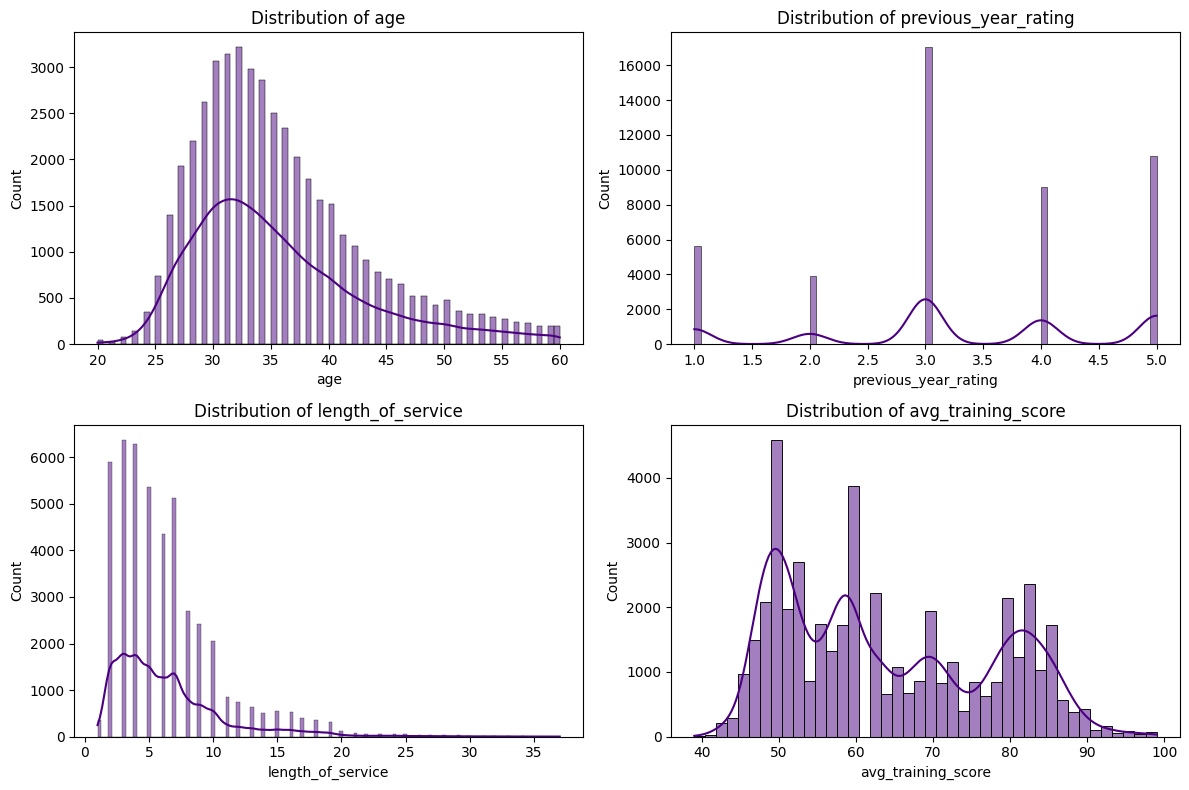

In [13]:
numerical_cols = ['age', 'previous_year_rating', 'length_of_service', 'avg_training_score']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i],color="indigo")
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

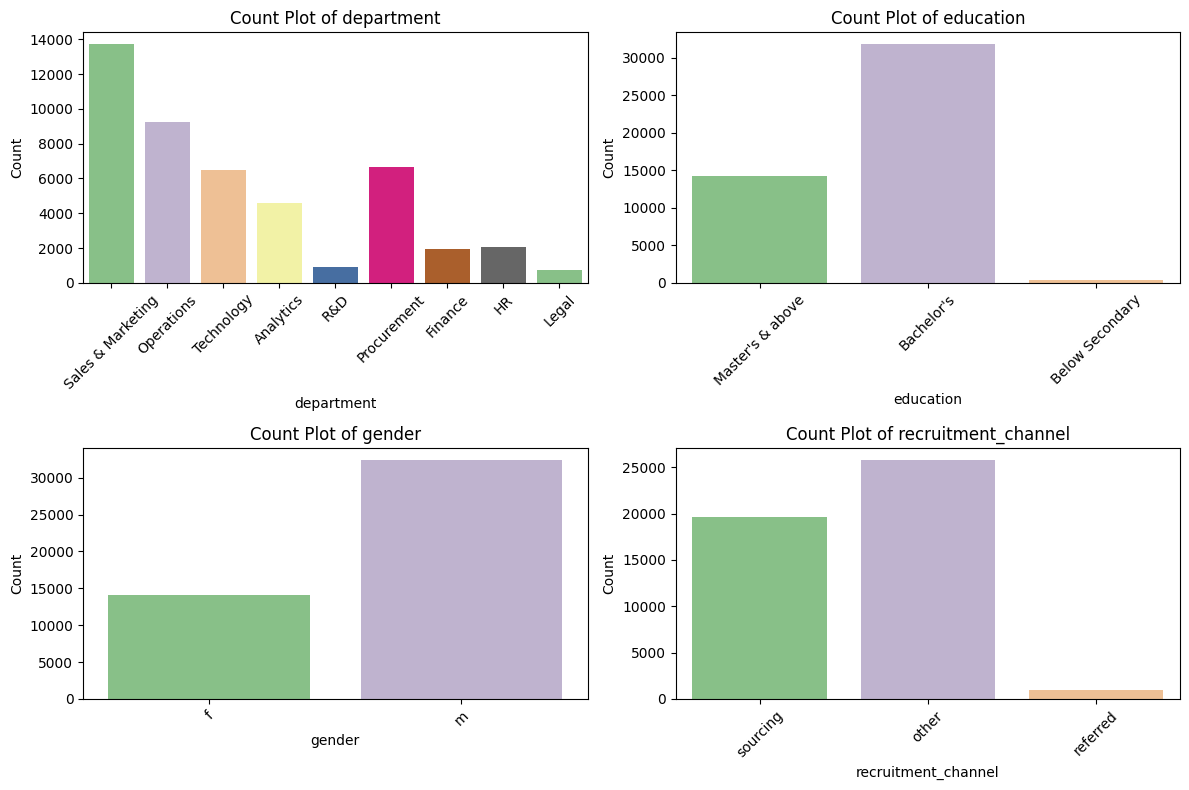

In [14]:
categorical_cols = ['department', 'education', 'gender', 'recruitment_channel']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i],palette="Accent")
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

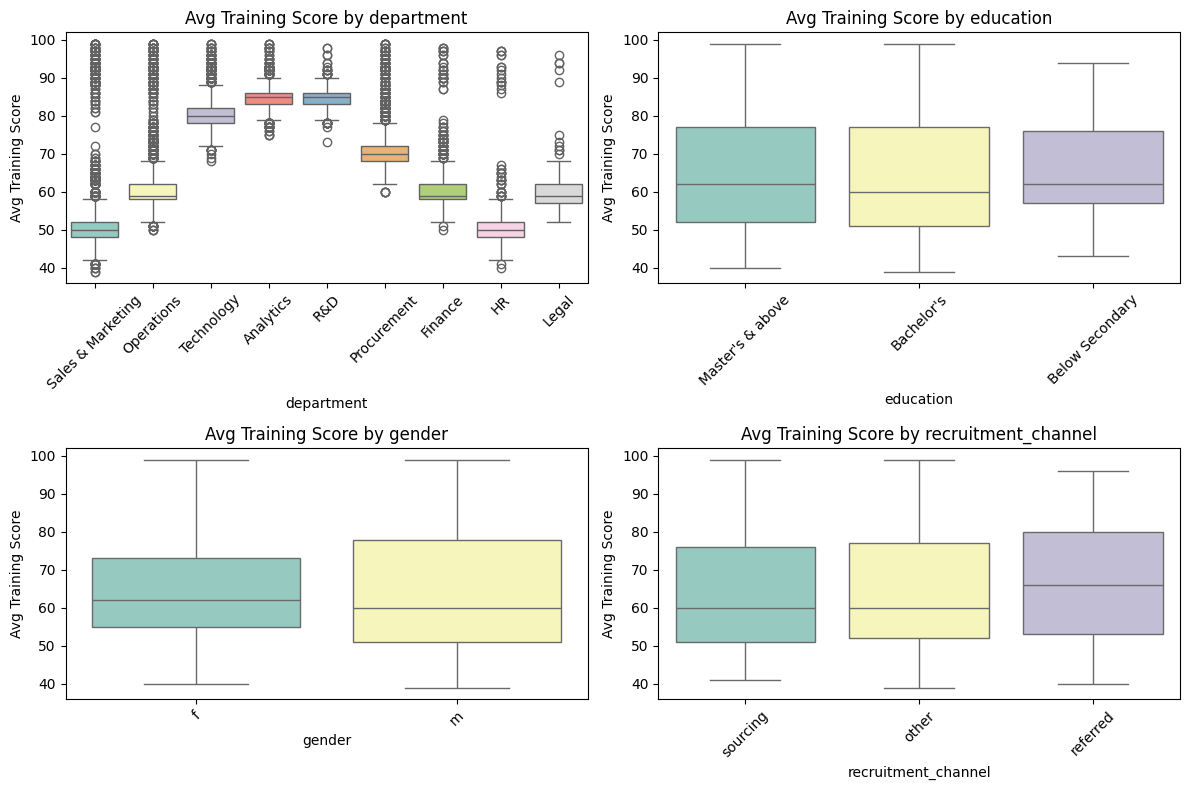

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(['department', 'education', 'gender', 'recruitment_channel']):
    sns.boxplot(data=df, x=col, y='avg_training_score', ax=axes[i],palette="Set3")
    axes[i].set_title(f'Avg Training Score by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Avg Training Score')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

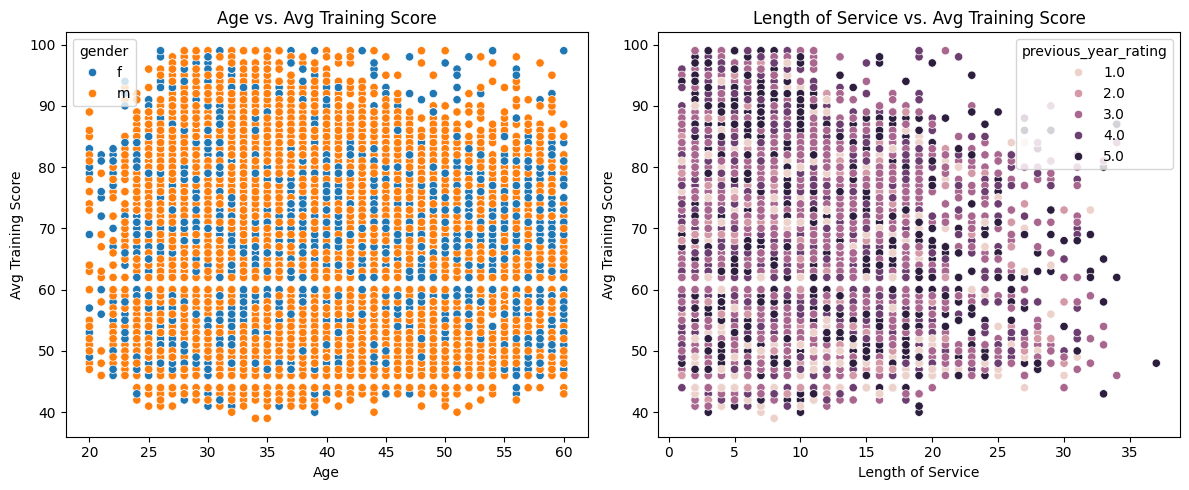

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x='age', y='avg_training_score', hue='gender', ax=axes[0])
axes[0].set_title('Age vs. Avg Training Score')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Avg Training Score')

sns.scatterplot(data=df, x='length_of_service', y='avg_training_score', hue='previous_year_rating', ax=axes[1])
axes[1].set_title('Length of Service vs. Avg Training Score')
axes[1].set_xlabel('Length of Service')
axes[1].set_ylabel('Avg Training Score')
plt.tight_layout()
plt.show()

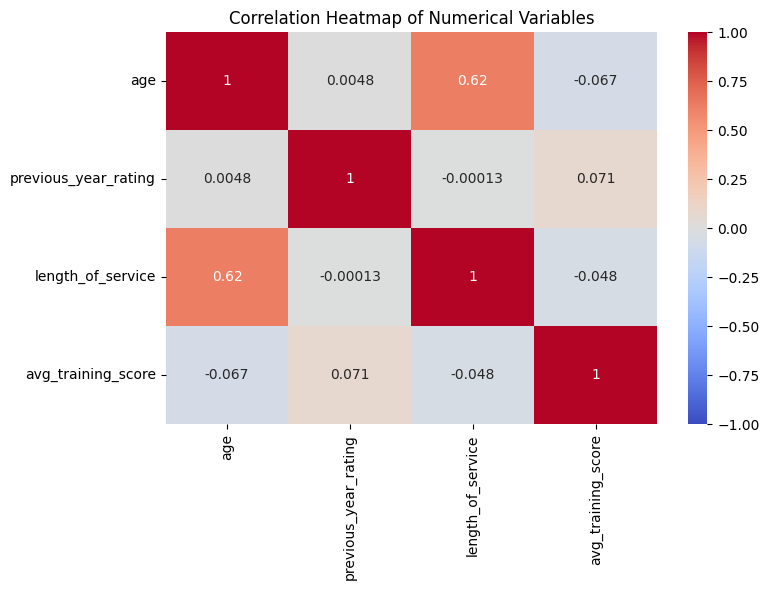

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

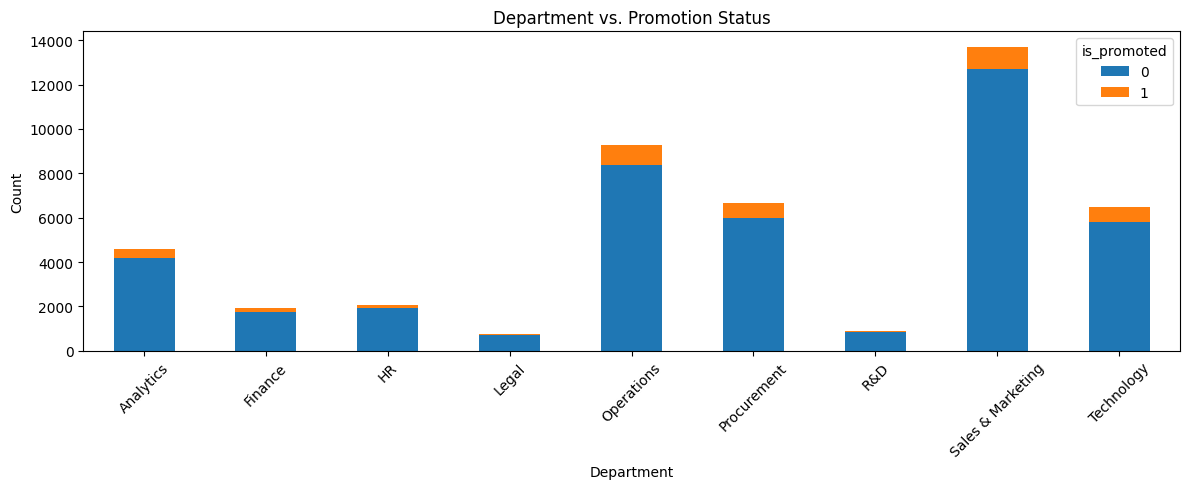

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
cross_tab = pd.crosstab(df['department'], df['is_promoted'])
cross_tab.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Department vs. Promotion Status')
ax.set_xlabel('Department')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [19]:
df.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0
3,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50.0,0
4,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73.0,0


In [20]:
cols_to_encode = ["gender", "region","education"]

# dictionary to store mappings
label_mappings = {}

# apply label encoding with mapping
for col in cols_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("\nLabel Encoding Mappings:")
for col, mapping in label_mappings.items():
    print(f"{col}: {mapping}")


Label Encoding Mappings:
gender: {'f': 0, 'm': 1}
region: {'region_1': 0, 'region_10': 1, 'region_11': 2, 'region_12': 3, 'region_13': 4, 'region_14': 5, 'region_15': 6, 'region_16': 7, 'region_17': 8, 'region_18': 9, 'region_19': 10, 'region_2': 11, 'region_20': 12, 'region_21': 13, 'region_22': 14, 'region_23': 15, 'region_24': 16, 'region_25': 17, 'region_26': 18, 'region_27': 19, 'region_28': 20, 'region_29': 21, 'region_3': 22, 'region_30': 23, 'region_31': 24, 'region_32': 25, 'region_33': 26, 'region_34': 27, 'region_4': 28, 'region_5': 29, 'region_6': 30, 'region_7': 31, 'region_8': 32, 'region_9': 33}
education: {"Bachelor's": 0, 'Below Secondary': 1, "Master's & above": 2}


In [21]:
df = pd.get_dummies(df, columns=["department", "recruitment_channel"], drop_first=False)
df = df.astype(int)

In [22]:
df.head()

,region,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted,...,department_HR,department_Legal,department_Operations,department_Procurement,department_R&D,department_Sales & Marketing,department_Technology,recruitment_channel_other,recruitment_channel_referred,recruitment_channel_sourcing
0,31,2,0,1,35,5,8,0,49,0,...,0,0,0,0,0,1,0,0,0,1
1,14,0,1,1,30,5,4,0,60,0,...,0,0,1,0,0,0,0,1,0,0
2,10,0,1,1,34,3,7,0,50,0,...,0,0,0,0,0,1,0,0,0,1
3,15,0,1,2,39,1,10,0,50,0,...,0,0,0,0,0,1,0,1,0,0
4,18,0,1,1,45,3,2,0,73,0,...,0,0,0,0,0,0,1,1,0,0


In [23]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

X = df.drop("is_promoted", axis=1)
y = df["is_promoted"]

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Top 5 features:", list(selected_features))
df=pd.concat([df[selected_features], y], axis=1)

Top 5 features: ['previous_year_rating', 'awards_won', 'avg_training_score', 'department_Sales & Marketing', 'department_Technology']


In [24]:
df.head()

,previous_year_rating,awards_won,avg_training_score,department_Sales & Marketing,department_Technology,is_promoted
0,5,0,49,1,0,0
1,5,0,60,0,0,0
2,3,0,50,1,0,0
3,1,0,50,1,0,0
4,3,0,73,0,1,0


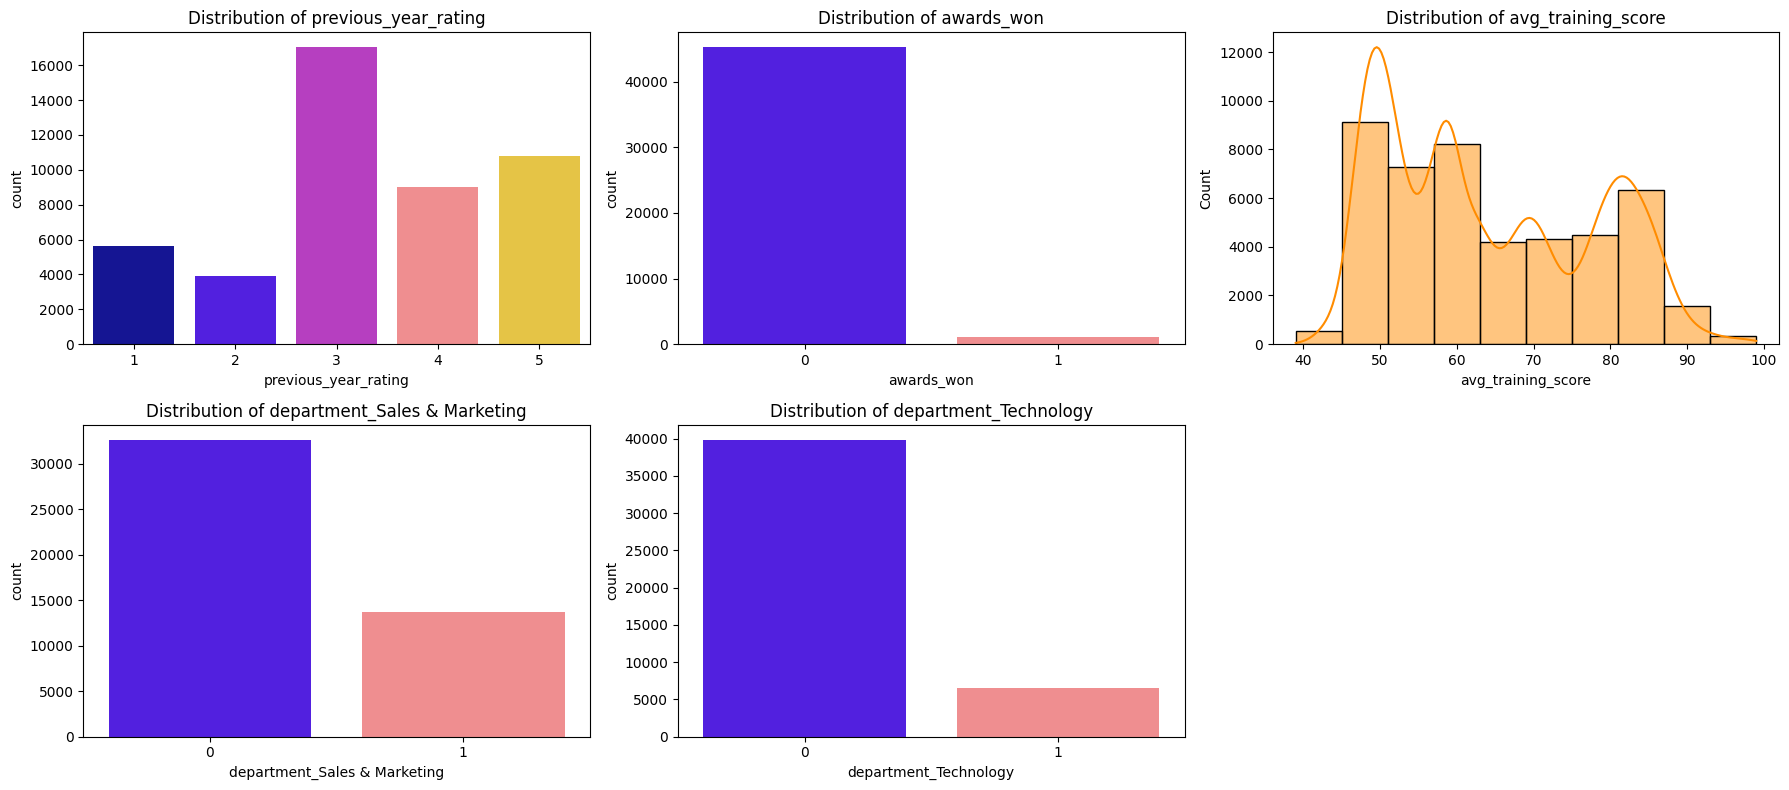

In [25]:
features = ['previous_year_rating', 'awards_won', 'avg_training_score',
            'department_Sales & Marketing', 'department_Technology']

plt.figure(figsize=(18, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    if df[feature].nunique() <= 10:  # categorical/binary
        sns.countplot(x=feature, data=df,palette="gnuplot2")
    else:  # numeric
        sns.histplot(df[feature], bins=10, kde=True,color="darkorange")
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
from evalml import AutoMLSearch
X = df.drop("is_promoted", axis=1)
y = df["is_promoted"]


X_train, X_test, y_train, y_test= evalml.preprocessing.split_data(X, y, problem_type="binary", test_size=0.2, random_seed=42)


In [27]:
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (37104, 5) (37104,)
Test shape: (9276, 5) (9276,)


In [28]:
from evalml.objectives import F1, Precision, Recall

In [29]:
automl=AutoMLSearch(X_train=X_train,y_train=y_train,problem_type="binary",max_batches=1,optimize_thresholds=True,additional_objectives=[F1(),Precision(),Recall()],verbose=True)
automl.search()


AutoMLSearch will use mean CV score to rank pipelines.


INFO:evalml.automl.automl_search.verbose:AutoMLSearch will use mean CV score to rank pipelines.



*****************************


INFO:evalml.automl.automl_search.verbose:
*****************************


* Beginning pipeline search *


...

Best pipeline: Random Forest Classifier w/ Label Encoder + Imputer + Undersampler + RF Classifier Select From Model


INFO:evalml.automl.automl_search.verbose:Best pipeline: Random Forest Classifier w/ Label Encoder + Imputer + Undersampler + RF Classifier Select From Model


Best pipeline Log Loss Binary: 0.287142


INFO:evalml.automl.automl_search.verbose:Best pipeline Log Loss Binary: 0.287142


{1: {'Random Forest Classifier w/ Label Encoder + Imputer + Undersampler + RF Classifier Select From Model': 4.661101818084717,
  'Total time of batch': 4.818665504455566}}

In [30]:
automl.rankings

,id,pipeline_name,search_order,ranking_score,mean_cv_score,standard_deviation_cv_score,percent_better_than_baseline,high_variance_cv,parameters
0,1,Random Forest Classifier w/ Label Encoder + Im...,1,0.287142,0.287142,0.004803,90.924489,False,"{'Label Encoder': {'positive_label': None}, 'I..."
1,0,Mode Baseline Binary Classification Pipeline,0,3.163922,3.163922,0.001683,0.000000,False,"{'Label Encoder': {'positive_label': None}, 'B..."


In [31]:
best_pipeline = automl.best_pipeline
automl.describe_pipeline(automl.rankings.iloc[1]["id"])


************************************************


INFO:evalml.pipelines.pipeline_base.describe:
************************************************


* Mode Baseline Binary Classification Pipeline *


INFO:evalml.pipelines.pipeline_base.describe:* Mode Baseline Binary Classification Pipeline *


************************************************


...

INFO:evalml.automl.automl_search.describe_pipeline:Cross Validation


----------------


INFO:evalml.automl.automl_search.describe_pipeline:----------------


             Log Loss Binary    F1  Precision  Recall # Training # Validation
0                      3.162 0.000      0.000   0.000     24,736       12,368
1                      3.165 0.000      0.000   0.000     24,736       12,368
2                      3.165 0.000      0.000   0.000     24,736       12,368
mean                   3.164 0.000      0.000   0.000          -            -
std                    0.002 0.000      0.000   0.000          -            -
coef of var            0.001   inf        inf     inf          -            -


INFO:evalml.automl.automl_search.describe_pipeline:             Log Loss Binary    F1  Precision  Recall # Training # Validation
0                      3.162 0.000      0.000   0.000     24,736       12,368
1                      3.165 0.000      0.000   0.000     24,736       12,368
2                      3.165 0.000      0.000   0.000     24,736       12,368
mean                   3.164 0.000      0.000   0.000          -            -
std                    0.002 0.000      0.000   0.000          -            -
coef of var            0.001   inf        inf     inf          -            -


In [32]:
from evalml.objectives import get_core_objectives
import pandas as pd

objectives = get_core_objectives("binary")
metrics = best_pipeline.score(X_test, y_test, objectives=objectives)

metrics_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Score"])
print(metrics_df)

                     Metric     Score
0                MCC Binary  0.308035
1           Log Loss Binary  0.287684
2                      Gini  0.517951
3                       AUC  0.758976
4                 Precision  0.399110
5                        F1  0.361559
6  Balanced Accuracy Binary  0.641303
7           Accuracy Binary  0.897585


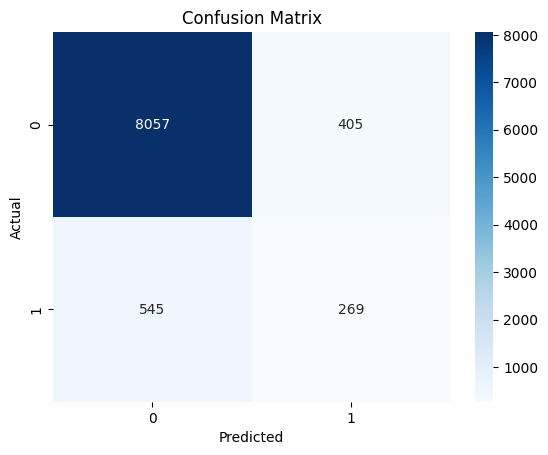

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      8462
           1       0.40      0.33      0.36       814

    accuracy                           0.90      9276
   macro avg       0.67      0.64      0.65      9276
weighted avg       0.89      0.90      0.89      9276



In [33]:
from sklearn.metrics import confusion_matrix, classification_report


y_pred = best_pipeline.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
report = classification_report(y_test, y_pred)
print(report)

In [34]:
best_pipeline.save("model.pkl")
final_model=automl.load('model.pkl')
pred=final_model.predict(X_test)
X_test["is_promoted_pred"]=pred
X_test["is_promoted_true"] = y_test
X_test.head()

,previous_year_rating,awards_won,avg_training_score,department_Sales & Marketing,department_Technology,is_promoted_pred,is_promoted_true
34349,3,0,50,0,0,0,0
7603,3,0,83,0,0,0,0
45599,5,0,51,1,0,0,0
11207,3,0,60,0,0,0,0
26148,3,0,75,0,1,0,0


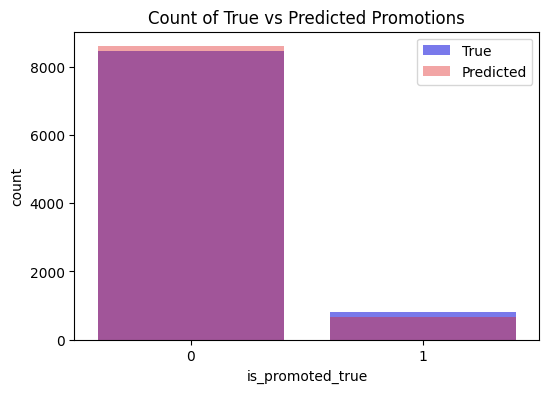

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x="is_promoted_true", data=X_test, label='True', color='blue', alpha=0.6)
sns.countplot(x="is_promoted_pred", data=X_test, label='Pred', color='red', alpha=0.4)
plt.title("Count of True vs Predicted Promotions")
plt.legend(["True", "Predicted"])
plt.show()

<Figure size 1200x400 with 0 Axes>

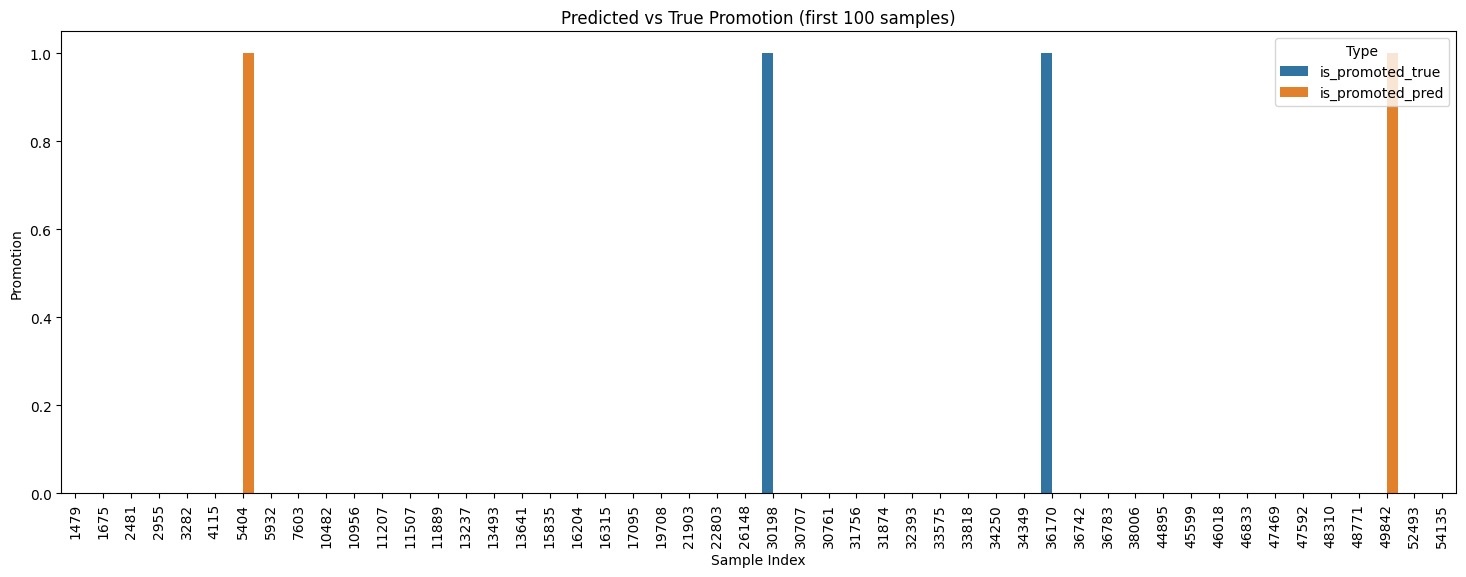

In [36]:
plt.figure(figsize=(12,4))
df_sample = X_test.head(50)
df_melt = df_sample[["is_promoted_true", "is_promoted_pred"]].reset_index().melt(id_vars="index",
                                                                                value_vars=["is_promoted_true", "is_promoted_pred"],
                                                                                var_name="Type", value_name="Promotion")

# Plot with Seaborn
plt.figure(figsize=(18,6))
sns.barplot(x="index", y="Promotion", hue="Type", data=df_melt)
plt.title("Predicted vs True Promotion (first 100 samples)")
plt.xlabel("Sample Index")
plt.ylabel("Promotion")
plt.xticks(rotation=90)
plt.legend(title="Type")
plt.show()

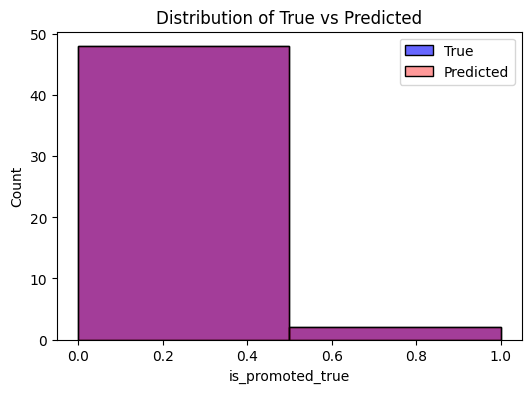

In [37]:
plt.figure(figsize=(6,4))
sns.histplot(df_sample["is_promoted_true"], color='blue', kde=False, label='True', bins=2, alpha=0.6)
sns.histplot(df_sample["is_promoted_pred"], color='red', kde=False, label='Predicted', bins=2, alpha=0.4)
plt.title("Distribution of True vs Predicted")
plt.legend()
plt.show()